<a href="https://colab.research.google.com/github/Neeraja-577/Machine-Learning/blob/main/Decision_tree_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:


df=pd.read_csv("/content/penguins_size.csv")
df

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [5]:
df.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [6]:
df.shape

(344, 7)

In [7]:
df.size


2408

In [8]:
df.columns

Index(['species', 'island', 'culmen_length_mm', 'culmen_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')

In [9]:
df.isnull().sum()

,0
species,0
island,0
culmen_length_mm,2
culmen_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,10


In [10]:
df.isnull()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,True,True,True,True,True
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
339,False,False,True,True,True,True,True
340,False,False,False,False,False,False,False
341,False,False,False,False,False,False,False
342,False,False,False,False,False,False,False


In [11]:
df.head()


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [12]:
df.tail()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE
343,Gentoo,Biscoe,49.9,16.1,213.0,5400.0,MALE


In [13]:
df['species'].value_counts()

,count
species,
Adelie,152
Gentoo,124
Chinstrap,68


In [14]:
import warnings
warnings.filterwarnings('ignore')

In [15]:
df['species'].unique

<bound method Series.unique of 0      Adelie
1      Adelie
2      Adelie
3      Adelie
4      Adelie
        ...  
339    Gentoo
340    Gentoo
341    Gentoo
342    Gentoo
343    Gentoo
Name: species, Length: 344, dtype: object>

In [16]:
df=df[df['sex']!='.']
df.shape

(343, 7)

In [17]:
df['culmen_length_mm'].fillna(df['culmen_length_mm'].mean())
df['body_mass_g'].fillna(df['body_mass_g'].mean())
df['flipper_length_mm'].fillna(df['flipper_length_mm'].median())
df['sex'].fillna(df['sex'].mode()[0])

,sex
0,MALE
1,FEMALE
2,FEMALE
3,MALE
4,FEMALE
...,...
339,MALE
340,FEMALE
341,MALE
342,FEMALE


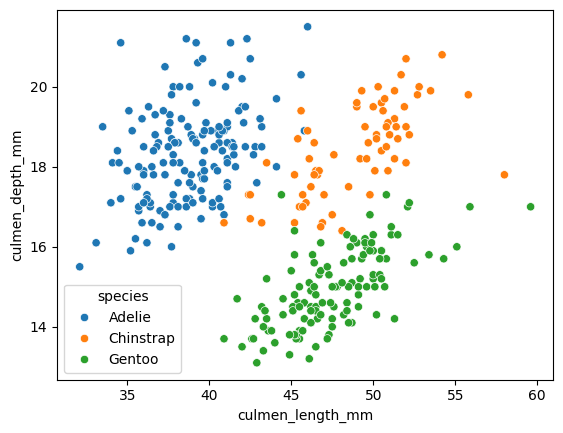

In [18]:
sns.scatterplot(x='culmen_length_mm',y='culmen_depth_mm',data=df,hue='species')
plt.show()

# LABEL ENCODING


In [19]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["species"]=le.fit_transform(df["species"])
df["island"]=le.fit_transform(df["island"])
df["sex"]=le.fit_transform(df["sex"])
df

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,0,2,39.1,18.7,181.0,3750.0,1
1,0,2,39.5,17.4,186.0,3800.0,0
2,0,2,40.3,18.0,195.0,3250.0,0
3,0,2,NaN,NaN,NaN,NaN,2
4,0,2,36.7,19.3,193.0,3450.0,0
...,...,...,...,...,...,...,...
339,2,0,NaN,NaN,NaN,NaN,2
340,2,0,46.8,14.3,215.0,4850.0,0
341,2,0,50.4,15.7,222.0,5750.0,1
342,2,0,45.2,14.8,212.0,5200.0,0


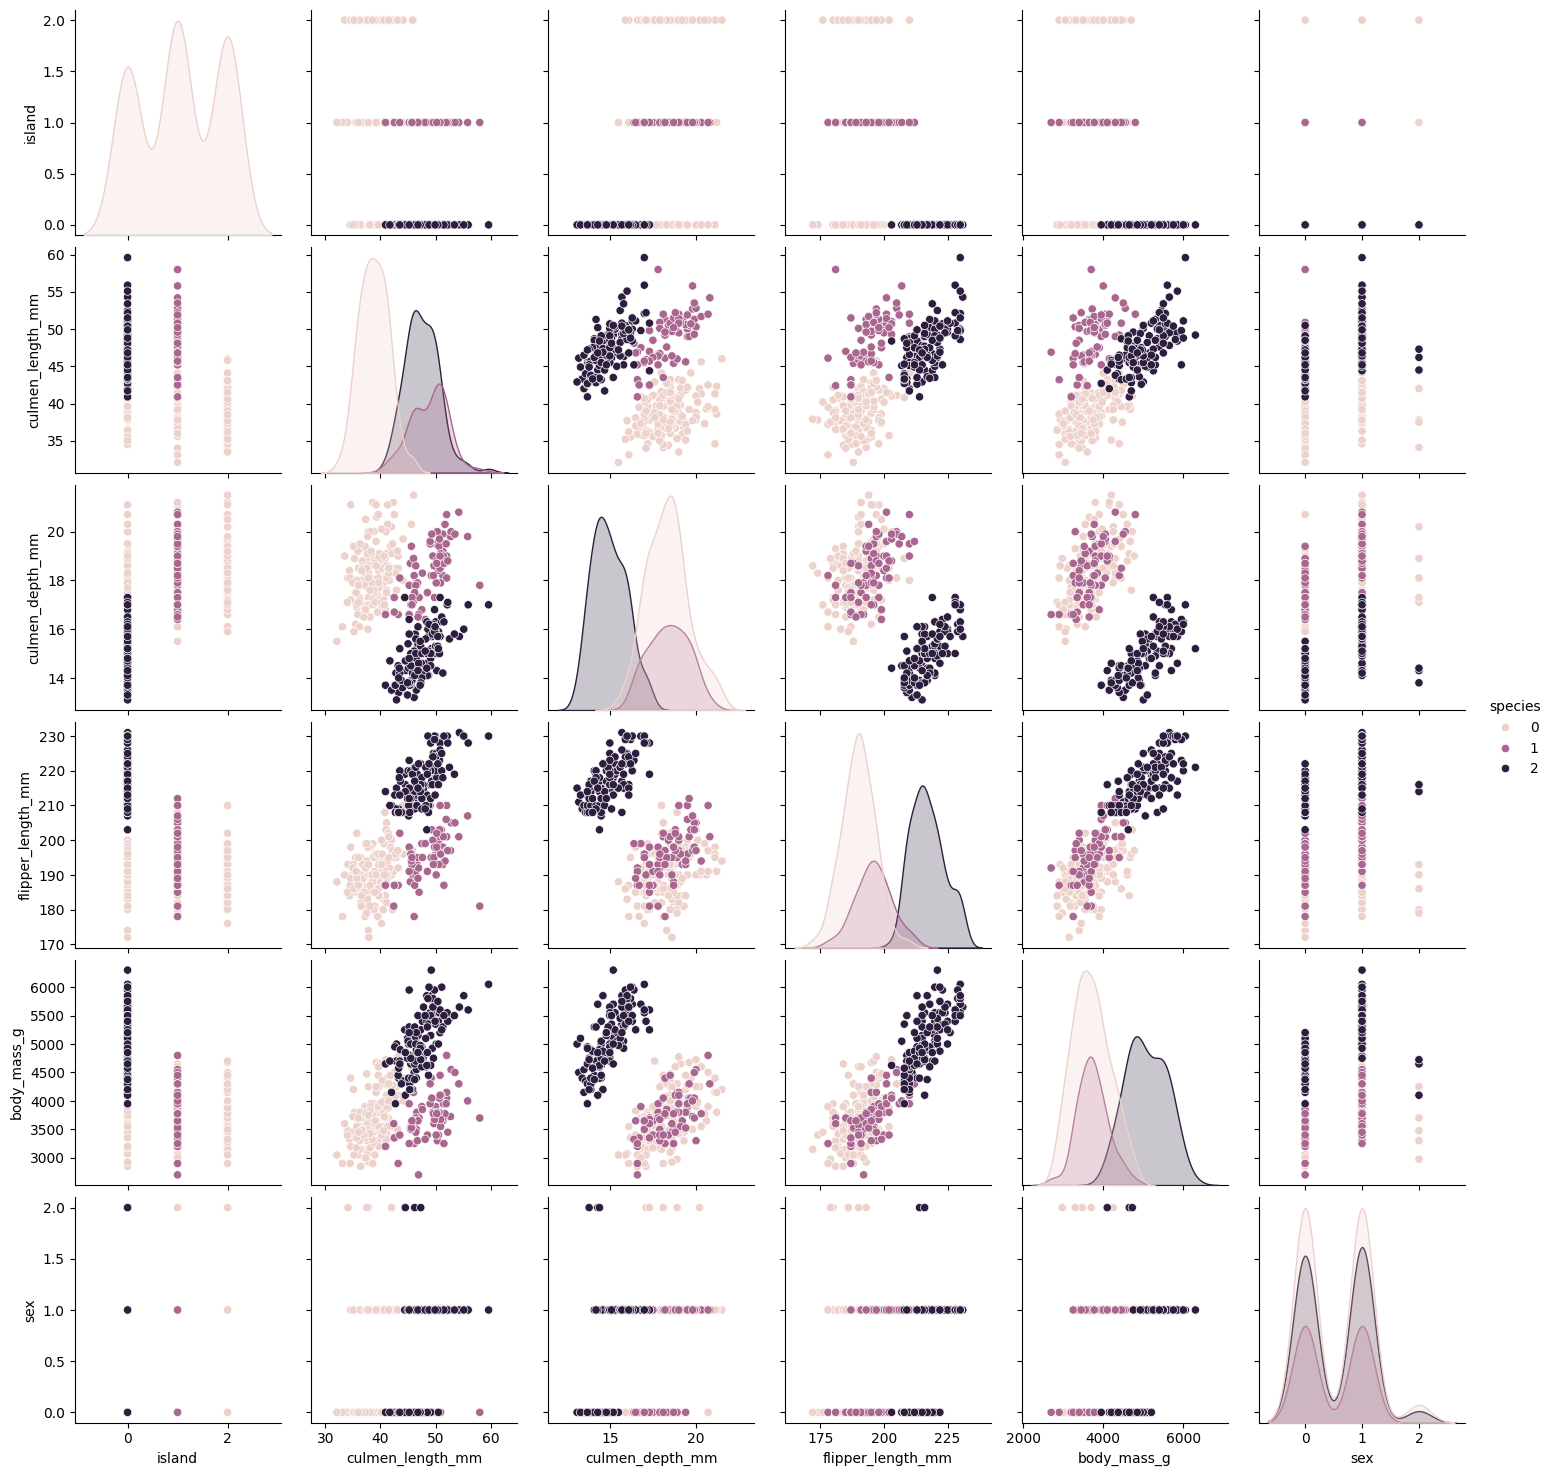

In [20]:
sns.pairplot(df,hue='species')
plt.show()

In [21]:
df.corr()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
species,1.000000,-0.634561,0.732588,-0.743654,0.853717,0.749896,-0.000621
island,-0.634561,1.000000,-0.353802,0.570213,-0.564532,-0.560529,0.036566
culmen_length_mm,0.732588,-0.353802,1.000000,-0.235015,0.657102,0.595476,0.273461
culmen_depth_mm,-0.743654,0.570213,-0.235015,1.000000,-0.582964,-0.470963,0.320777
flipper_length_mm,0.853717,-0.564532,0.657102,-0.582964,1.000000,0.870956,0.209650
body_mass_g,0.749896,-0.560529,0.595476,-0.470963,0.870956,1.000000,0.358774
sex,-0.000621,0.036566,0.273461,0.320777,0.209650,0.358774,1.000000


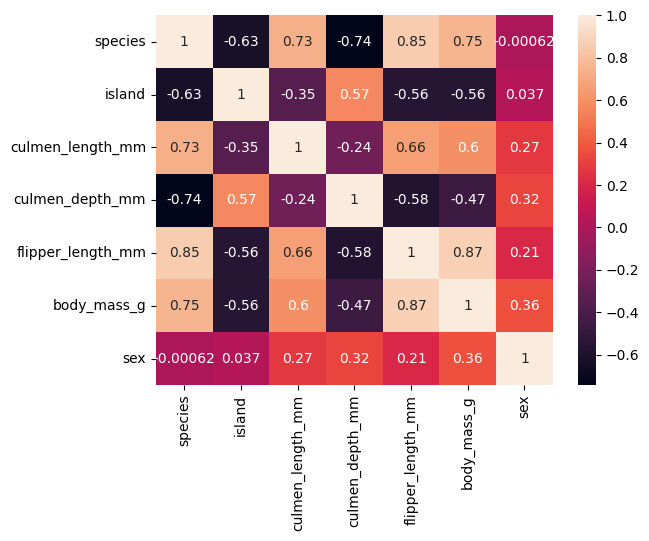

In [22]:
sns.heatmap(df.corr(),annot=True)
plt.show()

In [23]:
df.isna().sum()

,0
species,0
island,0
culmen_length_mm,2
culmen_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,0


In [24]:
df['culmen_length_mm'].fillna(df['culmen_length_mm'].mean())

,culmen_length_mm
0,39.100000
1,39.500000
2,40.300000
3,43.920235
4,36.700000
...,...
339,43.920235
340,46.800000
341,50.400000
342,45.200000


In [25]:
df.isna().sum()

,0
species,0
island,0
culmen_length_mm,2
culmen_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,0


In [26]:
df['culmen_length_mm'].fillna(df['culmen_length_mm'].mean(), inplace=True)
df['culmen_depth_mm'].fillna(df['culmen_depth_mm'].mean(), inplace=True)
df['flipper_length_mm'].fillna(df['flipper_length_mm'].mean(), inplace=True)
df['body_mass_g'].fillna(df['body_mass_g'].mean(), inplace=True)

In [27]:
df.isna().sum()

,0
species,0
island,0
culmen_length_mm,0
culmen_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,0


# TRAIN TEST SPLIT

In [28]:
x=df.drop(columns="species")
y=df["species"]

In [29]:
df1=df.drop("species",axis=1)
X=pd.get_dummies(df1,drop_first=True)

In [30]:
y=df['species']

In [31]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.5,random_state=42)

# DECISION TREE ALGORITHM

In [32]:
from sklearn.tree import DecisionTreeClassifier
dt_default = DecisionTreeClassifier(random_state=0)

dt_default.fit(x_train,y_train)

# Prediction
pred_train = dt_default.predict(x_train)
base_pred = dt_default.predict(x_test)

# Evaluation
# 1. Train & test accuracy
from sklearn.metrics import accuracy_score

print("Train accuracy:", accuracy_score(pred_train,y_train))
print("Test accuracy:", accuracy_score(base_pred,y_test))

# 2.cross validation score
from sklearn.model_selection import cross_val_score

scores = cross_val_score(dt_default,x,y,cv=5)
print("Cross Validation Score:", scores.mean())

Train accuracy: 1.0
Test accuracy: 0.9476744186046512
Cross Validation Score: 0.9736572890025575


In [33]:
dt_default.predict(pd.DataFrame([[30, 20, 150, 4000, 0, 1]], columns=['island', 'culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']))

array([1])

In [34]:
dt_default.predict([[30,20,150,4000,1,0]])

array([1])

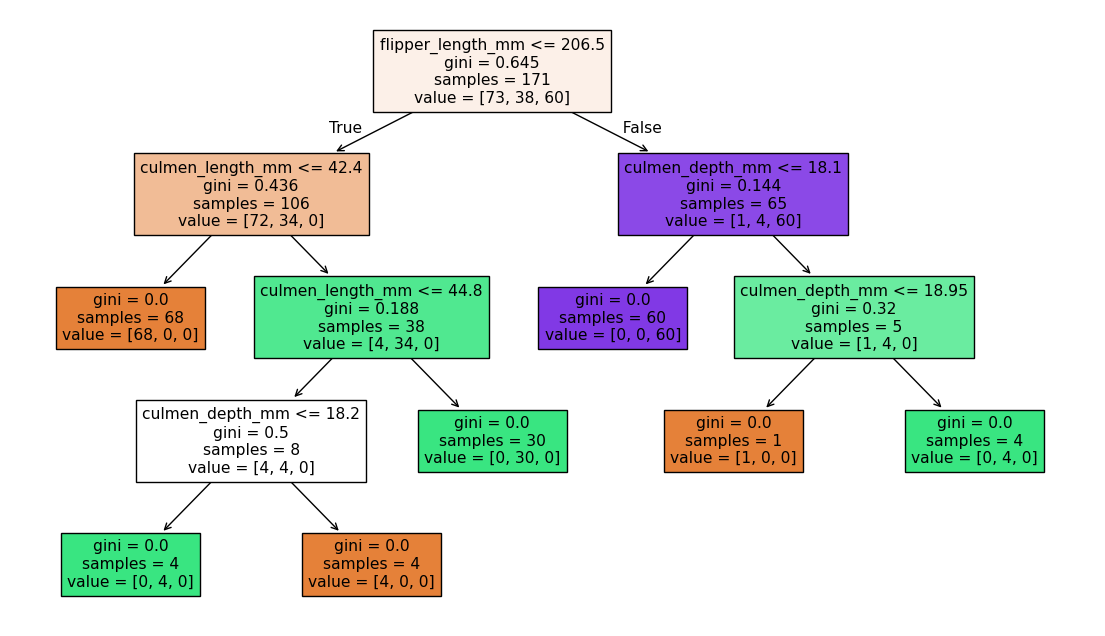

In [35]:
from sklearn.tree import plot_tree
plt.figure(figsize=(14,8),dpi=100)
plot_tree(dt_default,filled=True,feature_names=x.columns)
plt.show()

In [45]:
dt_default.feature_importances_


array([0.        , 0.38235447, 0.12102542, 0.49662011, 0.        ,
       0.        ])

In [46]:
pd.DataFrame(data=dt_default.feature_importances_, index=x.columns, columns=["Feature Importances"])

,Feature Importances
island,0.000000
culmen_length_mm,0.382354
culmen_depth_mm,0.121025
flipper_length_mm,0.496620
body_mass_g,0.000000
sex,0.000000


In [47]:
from sklearn.model_selection import GridSearchCV

# model
estimator = DecisionTreeClassifier(random_state=0)

# parameters & values
param_grid = {"criterion":["gini","entropy"],
              "max_depth":[1,2,3,4]}

# Identifying the best value of the parameter within given values
grid=GridSearchCV(estimator,param_grid,scoring="accuracy",cv=5)
grid.fit(x_train,y_train)

# Output the best parameter found
grid.best_params_

{'criterion': 'entropy', 'max_depth': 4}

In [48]:
x = x.drop(["body_mass_g","island","sex"],axis=1)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=0)

dt_bhp = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=0)
dt_bhp.fit(x_train,y_train)

ypred_train = dt_bhp.predict(x_train)
ypred_test = dt_bhp.predict(x_test)

print("Train accuracy:", accuracy_score(ypred_train,y_train))
print("Test accuracy:", accuracy_score(ypred_test,y_test))

scores = cross_val_score(dt_bhp,x,y,cv=5)
print("Cross Validation Score:",scores.mean())


Train accuracy: 0.9791666666666666
Test accuracy: 0.9902912621359223
Cross Validation Score: 0.9385763000852515


In [49]:
def report_model(model):
  model.fit(x_train,y_train)
  model_preds=model.predict(x_test)
  pred_train=model.predict(x_train)
  print("Train Accuracy:",accuracy_score(y_train,pred_train))
  print("Test Accuracy:",accuracy_score(y_test,model_preds))
  plt.figure(figsize=(12,8),dpi=150)
  plot_tree(model,filled=True,feature_names=x.columns)

Train Accuracy: 0.9625
Test Accuracy: 0.9902912621359223


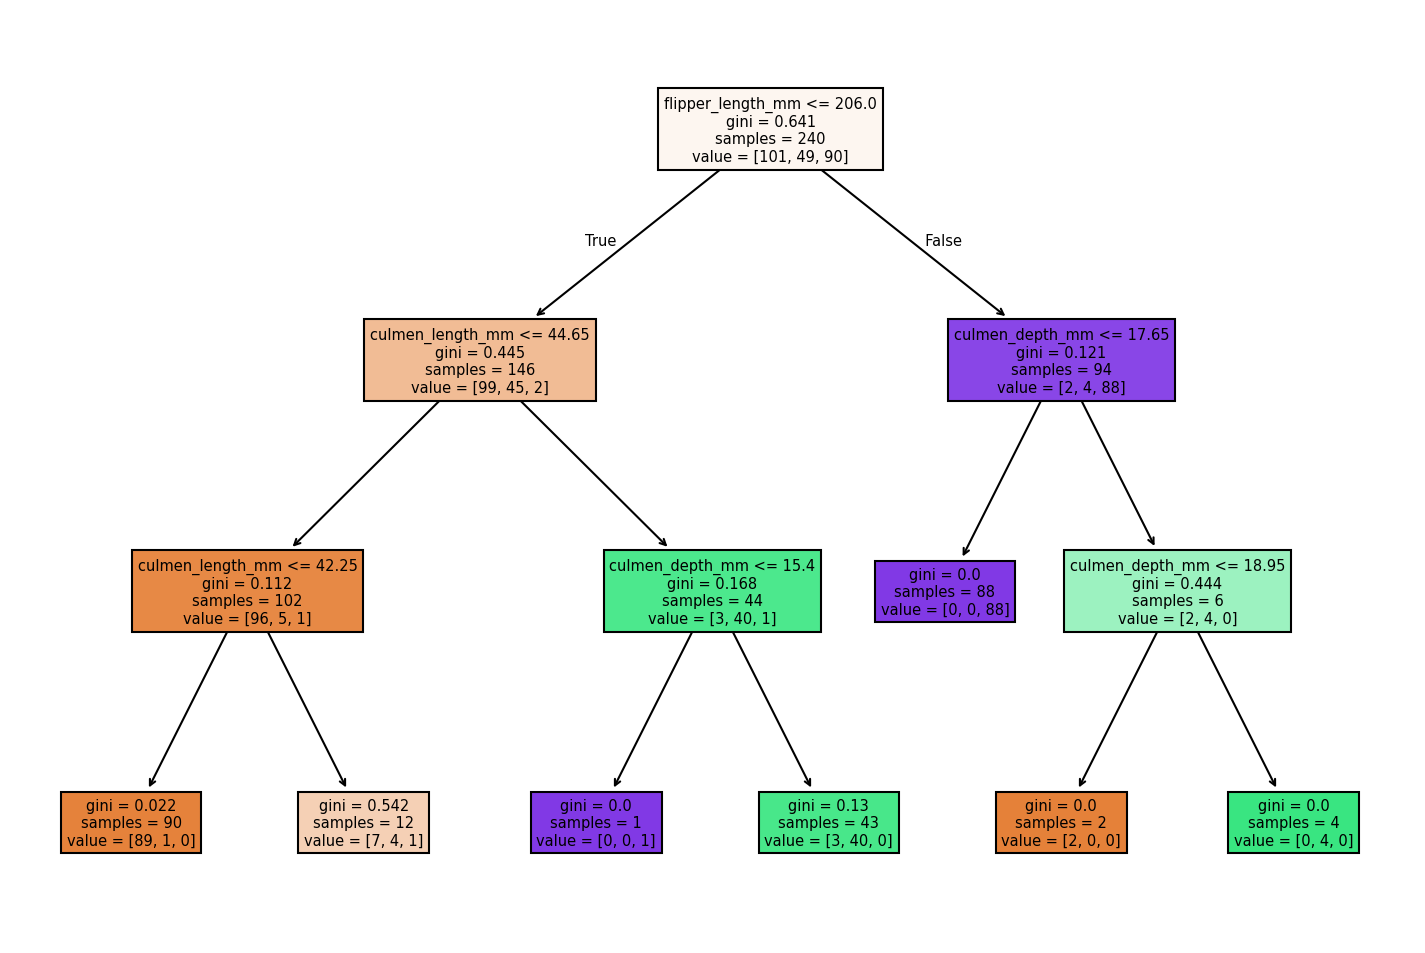

In [50]:
pruned_tree=DecisionTreeClassifier(max_depth=3)
report_model(pruned_tree)

Train Accuracy: 0.9625
Test Accuracy: 0.9902912621359223


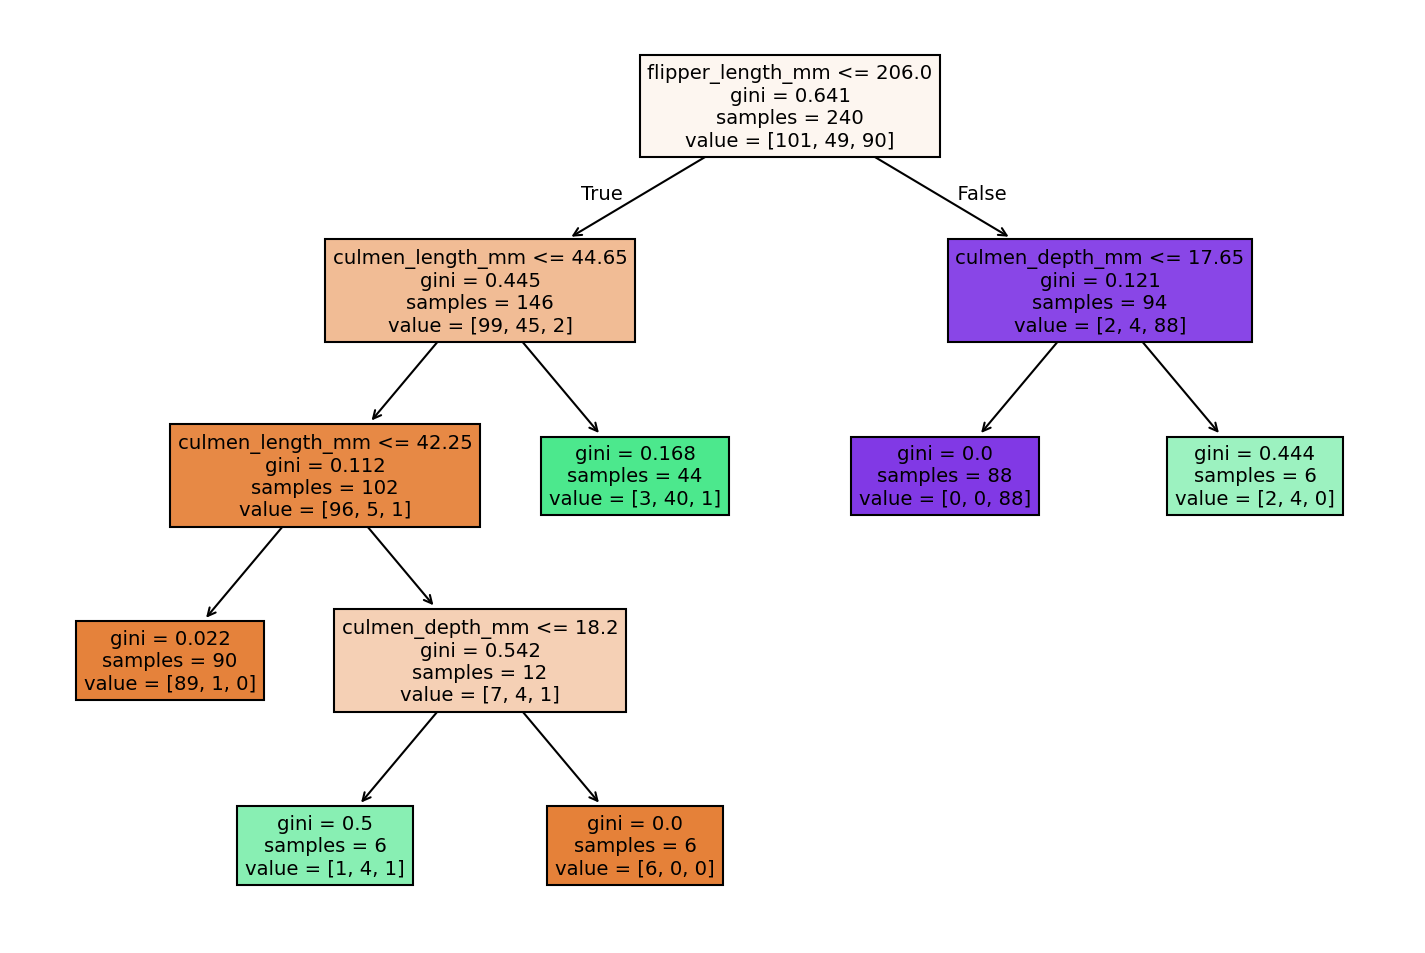

In [51]:
pruned_tree=DecisionTreeClassifier(max_leaf_nodes=6)
report_model(pruned_tree)

# KNN

In [36]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [37]:
#Default modeling
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier()
knn_model.fit(x_train , y_train)

#prediction
y_pred_train = knn_model.predict(x_train)
y_pred_test = knn_model.predict(x_test)

#Evaluation
#1.Train & test accuracy
from sklearn.metrics import accuracy_score
print(accuracy_score(y_train,y_pred_train))
print(accuracy_score(y_test,y_pred_test))

#2.cross validation
from sklearn.model_selection import cross_val_score
scores=cross_val_score(knn_model,x,y,cv=5)
print(scores)
cv_score=scores.mean()
print('Cross Validation Score:',cv_score)

1.0
0.9941860465116279
[0.71014493 0.79710145 0.71014493 0.82352941 0.89705882]
Cross Validation Score: 0.7875959079283887


In [38]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier()
knn_model.fit(x_train , y_train)

KNeighborsClassifier()

In [39]:
from sklearn.model_selection import GridSearchCV

estimator = KNeighborsClassifier()
param_grid = {'n_neighbors':list(range(1,31)),'p':[1,2]}

cv_classifier = GridSearchCV(estimator, param_grid, cv = 5, scoring = 'accuracy')
cv_classifier.fit(x_train, y_train)
cv_classifier.best_params_

{'n_neighbors': 1, 'p': 1}

In [40]:
knn_model = KNeighborsClassifier(n_neighbors = 1, p=1)
knn_model.fit(x_train , y_train)

#prediction
y_pred_train = knn_model.predict(x_train)
y_pred_test = knn_model.predict(x_test)

#Evaluation
#1.Train & test accuracy
print(accuracy_score(y_train,y_pred_train))
print(accuracy_score(y_test,y_pred_test))

#2.cross validation
scores=cross_val_score(knn_model,x,y,cv=5)
print(scores)
cv_score=scores.mean()
print('Cross Validation Score:',cv_score)

1.0
0.9941860465116279
[0.7826087  0.85507246 0.84057971 0.86764706 0.94117647]
Cross Validation Score: 0.8574168797953965


# CONFUSION MATRIX

In [41]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred_test)

array([[78,  1,  0],
       [ 0, 30,  0],
       [ 0,  0, 63]])

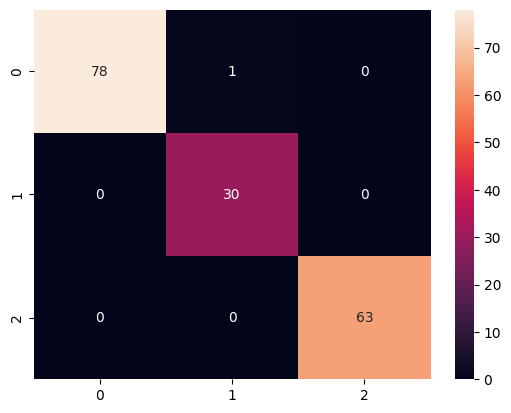

In [42]:
sns.heatmap(confusion_matrix(y_test,y_pred_test),annot=True)
plt.show()

In [43]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99        79
           1       0.97      1.00      0.98        30
           2       1.00      1.00      1.00        63

    accuracy                           0.99       172
   macro avg       0.99      1.00      0.99       172
weighted avg       0.99      0.99      0.99       172



# SVC (SUPPORT VECTOR CLASSIFIER)

In [44]:
#Default modeling
from sklearn.svm import SVC
model = SVC()
model.fit(x_train , y_train)

#prediction
ypred_train = model.predict(x_train)
ypred_test = model.predict(x_test)

#Evaluation
#1.Train & test accuracy
from sklearn.metrics import accuracy_score
print(accuracy_score(y_train,ypred_train))
print(accuracy_score(y_test,ypred_test))

#2.cross validation
from sklearn.model_selection import cross_val_score
scores=cross_val_score(model,x,y,cv=5)
print(scores)
cv_score=scores.mean()
print('Cross Validation Score:',cv_score)

1.0
0.9883720930232558
[0.72463768 0.68115942 0.71014493 0.73529412 0.75      ]
Cross Validation Score: 0.7202472293265132


In [52]:
from sklearn.model_selection import GridSearchCV
estimator = SVC()
param_grid = {'C':[0.01,0.1,1,10,100],'kernel':['linear','rbf','sigmoid','poly']}

grid = GridSearchCV(estimator, param_grid, cv = 5)
grid.fit(x, y)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'kernel': ['linear', 'rbf', 'sigmoid', 'poly']})

In [53]:
model = SVC(C = 0.01,kernel = 'linear')
model.fit(x_train , y_train)

#prediction
ypred_train = model.predict(x_train)
ypred_test = model.predict(x_test)

#Evaluation
#1.Train & test accuracy
print(accuracy_score(y_train,ypred_train))
print(accuracy_score(y_test,ypred_test))

#2.cross validation
scores=cross_val_score(model,x,y,cv=5)
print(scores)
cv_score=scores.mean()
print('Cross Validation Score:',cv_score)

0.9583333333333334
0.9902912621359223
[0.98550725 0.98550725 0.95652174 0.94117647 0.94117647]
Cross Validation Score: 0.9619778346121057


In [54]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression()

In [55]:
log_model.fit(x_train, y_train)
ypred_train=log_model.predict(x_train)
ypred_test=log_model.predict(x_test)

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler # Import StandardScaler
from sklearn.metrics import accuracy_score     # Import accuracy_score
from sklearn.linear_model import LogisticRegression # Import LogisticRegression for classification

# Redefine X and y for classification task (predicting 'Outcome')
# This assumes `df` is the DataFrame containing all processed data.
X = df.drop(columns='species')
y = df['species']

# 1. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Added random_state

# 2. Scale
symmetric_scaler = StandardScaler()
X_train = symmetric_scaler.fit_transform(X_train)
X_test = symmetric_scaler.transform(X_test)

# 3. Train
# Re-instantiate 'model' as a LogisticRegression for the classification task
model = LogisticRegression(max_iter=1000) # Increased max_iter to help with convergence
model.fit(X_train, y_train)

# 4. Predict
ypred_train = model.predict(X_train)
ypred_test = model.predict(X_test)

# 5. Accuracy
print(accuracy_score(y_train, ypred_train))
print(accuracy_score(y_test, ypred_test))

1.0
0.9710144927536232


In [57]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_train,ypred_train))
print(accuracy_score(y_test,ypred_test))

1.0
0.9710144927536232


In [58]:
from sklearn.model_selection import cross_val_score
scores=cross_val_score(log_model,x,y,cv=5)
print(scores)
cv_score=scores.mean()
print('Cross Validation Score:',cv_score)

[0.98550725 0.98550725 0.97101449 1.         0.95588235]
Cross Validation Score: 0.9795822676896846


In [59]:
import pandas as pd

data = {
    "Algorithm": [
        "Logistic Regression",
        "Decision Tree",
        "KNN",
        "SVM",
    ],
    "Train accuracy": [0.9963636363636363,1.0,1.0,1.0],
    "Test accuracy": [0.9855072463768116,0.9476744186046512,0.9941860465116279,0.9883720930232558 ],
    "CV Score": [ 0.9825234441602728,0.9737851662404091,0.8578005115089514,0.9883720930232558 ]
}

df = pd.DataFrame(data)

print(df.to_string(index=True))

             Algorithm  Train accuracy  Test accuracy  CV Score
0  Logistic Regression        0.996364       0.985507  0.982523
1        Decision Tree        1.000000       0.947674  0.973785
2                  KNN        1.000000       0.994186  0.857801
3                  SVM        1.000000       0.988372  0.988372


# Save a model

In [60]:
from joblib import dump
import warnings
warnings.filterwarnings("ignore")

In [61]:
dump(knn_model,'svm_model.joblib')

['svm_model.joblib']

In [62]:
dump(model,'species.joblib')

['species.joblib']

# Load a model


In [63]:
from joblib import load

In [64]:
loaded_svm=load('svm_model.joblib')

# Prediction

In [65]:
model.predict(pd.DataFrame([[39.1,18.7,39.5,17.4,40.3,18.0]]))

array([1])

In [66]:
model.predict(pd.DataFrame([[0,1,1,0,0,1]]))

array([1])